In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("employee_turnover.csv")

In [3]:
df.columns

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

<Axes: xlabel='Employee_Turnover', ylabel='Job_Satisfaction'>

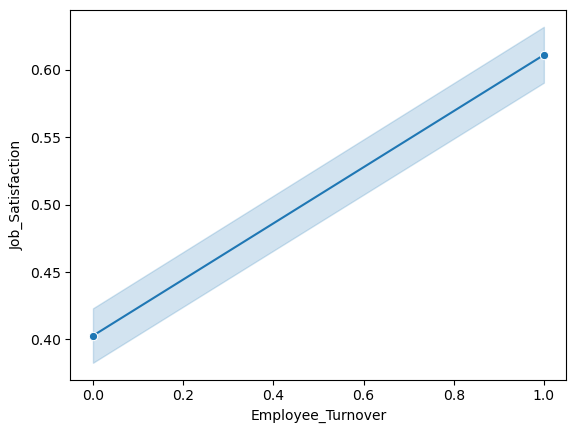

In [4]:
sns.lineplot(x = df["Employee_Turnover"], y = df["Job_Satisfaction"] , marker = "o")

In [5]:
X = df.drop("Employee_Turnover",axis = 1)
y  = df["Employee_Turnover"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
y_train[y_train == 1] 
y_train[y_train == 0] 

755     0
109     0
1040    0
774     0
983     0
       ..
330     0
1238    0
466     0
121     0
1044    0
Name: Employee_Turnover, Length: 533, dtype: int64

In [8]:
model = LogisticRegression(max_iter = 1500)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1500)

In [9]:
y_pred = model.predict(X_test)

In [10]:
y_pred

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0])

In [11]:
y_test

289     0
1036    0
535     1
346     0
1075    0
       ..
1280    1
435     0
722     0
54      1
382     0
Name: Employee_Turnover, Length: 270, dtype: int64

In [14]:
print("acuracy :" ,accuracy_score(y_test,y_pred)*100,"%")
print("precision :" ,precision_score(y_test,y_pred)*100,"%")
print("mse : ", mean_squared_error(y_test,y_pred))

acuracy : 85.92592592592592 %
precision : 87.17948717948718 %
mse :  0.14074074074074075


In [15]:
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

 MSE for alpha =0.001 :  0.11174392695771765
 MSE for alpha =0.1 :  0.24651909152005227
 MSE for alpha =1 :  0.2505221193415638
 MSE for alpha =2 :  0.2505221193415638
 MSE for alpha =3 :  0.2505221193415638
 MSE for alpha =10 :  0.2505221193415638
 MSE for alpha =20 :  0.2505221193415638
 MSE for alpha =30 :  0.2505221193415638
 MSE for alpha =40 :  0.2505221193415638


<Axes: >

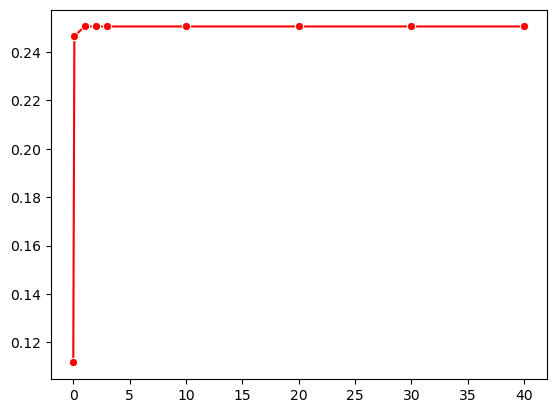

In [16]:
alpha = [0.001, 0.1 , 1 , 2 , 3, 10, 20, 30 , 40]
mses = []
for a in alpha:
    Elastic_model = ElasticNet(alpha = a,l1_ratio=0.5,)
    Elastic_model.fit(X_train,y_train)
    y_pred = Elastic_model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f" MSE for alpha ={a} : ", mse)
    mses.append(mse)

sns.lineplot(x = alpha,y = mses , marker = "o", color = "red")